# Pipe pre-check

In [1]:
import pandas as pd
from src.pipeline.rul_pipeline import RULPipeline

df = pd.read_csv('data/clean/data_motor_1.csv')
df.insert(0, 'unit_number', 1)

pipeline = RULPipeline(window_size=30, clipping_threshold=125, verbose=True)
motor_windows = pipeline.transform(df)

print(f"\nMotor 1:")
print(f"  X_windows shape: {motor_windows[1]['X_windows'].shape}")
print(f"  Eventos: {motor_windows[1]['evento'].sum()}")

[Nodo 2] 1 motors, 163 windows — 0.01s
[Nodo 3] 192 features per window — 2.88s
[Total]  2.89s

Motor 1:
  X_windows shape: (163, 192)
  Eventos: 1


In [1]:
"""Pipeline scale verification script.

Verifies the numerical ranges at each pipeline stage to detect
scaling issues that could affect model convergence.

Run from the project root:
    python pipeline_validation_scales.py
"""

import numpy as np
import pandas as pd

from src.pipeline.scaling import FeatureScaler
from src.pipeline.windowing import build_windows, flatten_windows
from src.pipeline.feature_extraction import extract_window_features
from src.pipeline.dim_reduction import DimReducer

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
WINDOW_SIZE = 30
CLIPPING_THRESHOLD = 125
N_COMPONENTS = 10
MOTOR_ID = 1

print("=" * 60)
print("PIPELINE SCALE VERIFICATION")
print("=" * 60)

# ---------------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------------
df = pd.read_csv(f'data/clean/data_motor_{MOTOR_ID}.csv')
df.insert(0, 'unit_number', MOTOR_ID)
X_df = df.drop(columns=['RUL'])

def print_range(label: str, arr: np.ndarray) -> None:
    """Prints min, max, mean and std of a numpy array."""
    flat = arr.flatten()
    print(f"  {label}:")
    print(f"    min={flat.min():.4f}, max={flat.max():.4f}, "
          f"mean={flat.mean():.4f}, std={flat.std():.4f}")

# ---------------------------------------------------------------------------
# Raw sensors
# ---------------------------------------------------------------------------
sensor_cols = [c for c in X_df.columns
               if c not in {'unit_number', 'time_in_cycles', 'evento'}]
print("\n[Raw sensors]")
print_range("X_raw", X_df[sensor_cols].to_numpy())

# ---------------------------------------------------------------------------
# Nodo 1 — FeatureScaler
# ---------------------------------------------------------------------------
scaler = FeatureScaler()
scaler.fit(X_df)
X_scaled: pd.DataFrame = scaler.transform(X_df)

print("\n[After Nodo 1 — FeatureScaler]")
print_range("X_scaled sensors", X_scaled[sensor_cols].to_numpy())

# ---------------------------------------------------------------------------
# Nodo 2 — build_windows
# ---------------------------------------------------------------------------
motor_windows = build_windows(X_scaled, window_size=WINDOW_SIZE,
                               clipping_threshold=CLIPPING_THRESHOLD)
data_w = motor_windows[MOTOR_ID]
print("\n[After Nodo 2 — build_windows]")
print_range("X_windows (3D)", data_w['X_windows'])

# ---------------------------------------------------------------------------
# Nodo 3 — extract_window_features
# ---------------------------------------------------------------------------
motor_features = extract_window_features(motor_windows)
data_f = motor_features[MOTOR_ID]
print("\n[After Nodo 3 — extract_window_features]")
print_range("X_features (2D)", data_f['X_windows'])
print(f"  n_features: {data_f['X_windows'].shape[1]}")
print(f"  Per-feature std range: "
      f"{data_f['X_windows'].std(axis=0).min():.4f} → "
      f"{data_f['X_windows'].std(axis=0).max():.4f}")

# ---------------------------------------------------------------------------
# Nodo 4 — DimReducer (PCA)
# ---------------------------------------------------------------------------
reducer = DimReducer(n_components=N_COMPONENTS)
reducer.fit(motor_features)
motor_reduced = reducer.transform(motor_features)
data_r = motor_reduced[MOTOR_ID]

print("\n[After Nodo 4 — PCA]")
print_range("X_pca (2D)", data_r['X_windows'])
print(f"  n_components: {data_r['X_windows'].shape[1]}")
print(f"  Per-component std:")
for i, std in enumerate(data_r['X_windows'].std(axis=0)):
    print(f"    PC_{i+1}: std={std:.4f}")

evr = reducer.explained_variance_ratio()
print(f"  Explained variance: {evr.round(3)}")

# ---------------------------------------------------------------------------
# Flatten
# ---------------------------------------------------------------------------
X, t_start, t_stop, evento, y_rul_nan, groups = flatten_windows(motor_reduced)

print("\n[After flatten_windows]")
print_range("X_flat", X)
print(f"  Shape: {X.shape}")
print(f"  NaN in X: {np.isnan(X).any()}")

# ---------------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------------
print("\n" + "=" * 60)
print("SCALE SUMMARY")
print("=" * 60)
print(f"  Raw sensors:     [{X_df[sensor_cols].to_numpy().min():.1f}, "
      f"{X_df[sensor_cols].to_numpy().max():.1f}]")
print(f"  After Nodo 1:    [{X_scaled[sensor_cols].to_numpy().min():.4f}, "
      f"{X_scaled[sensor_cols].to_numpy().max():.4f}]")
print(f"  After Nodo 3:    [{data_f['X_windows'].min():.4f}, "
      f"{data_f['X_windows'].max():.4f}]")
print(f"  After Nodo 4:    [{data_r['X_windows'].min():.4f}, "
      f"{data_r['X_windows'].max():.4f}]")
print(f"\n  ⚠️  If Nodo 4 range >> [-10, 10], consider adding")
print(f"     StandardScaler between Nodo 4 and the model.")

PIPELINE SCALE VERIFICATION

[Raw sensors]
  X_raw:
    min=-0.0067, max=9061.2100, mean=1698.6637, std=2725.4136

[After Nodo 1 — FeatureScaler]
  X_scaled sensors:
    min=-2.8896, max=2.8160, mean=0.0029, std=0.7947

[After Nodo 2 — build_windows]
  X_windows (3D):
    min=-2.8896, max=2.8160, mean=-0.0035, std=0.6878

[After Nodo 3 — extract_window_features]
  X_features (2D):
    min=-1.9723, max=103.6797, mean=1.1901, std=5.4627
  n_features: 192
  Per-feature std range: 0.0105 → 20.8211

[After Nodo 4 — PCA]
  X_pca (2D):
    min=-8.0887, max=51.2649, mean=-0.0000, std=4.6502
  n_components: 10
  Per-component std:
    PC_1: std=12.6231
    PC_2: std=4.2596
    PC_3: std=2.9869
    PC_4: std=2.6956
    PC_5: std=2.5486
    PC_6: std=2.2513
    PC_7: std=2.0455
    PC_8: std=1.7844
    PC_9: std=1.5559
    PC_10: std=1.1049
  Explained variance: [0.702 0.08  0.039 0.032 0.029 0.022 0.018 0.014 0.011 0.005]

[After flatten_windows]
  X_flat:
    min=-8.0887, max=51.2649, mean=-0.0

# BN pre check

PIPELINE VALIDATION — Phase 5: NB Predictions
Training engines: 140
Test engines: 60

Nodo 1 — scaling... 0.06s
Nodo 2 — windowing... 0.56s
Nodo 3 — feature extraction... 340.9s
Nodo 4 — PCA... 0.48s

Flatten:
  X_train: (15814, 10), NaN in y_rul_train: False
  X_val:   (3950, 10),   NaN in y_rul_val:   False

Nodo 5 — fitting NB... 0.139s  (fitted=True)

------------------------------------------------------------
RUL PREDICTIONS — validation set
------------------------------------------------------------
  MAE:  11.16 cycles
  RMSE: 15.88 cycles
  RUL pred range:  1.9 → 125.0
  RUL true range:  0.0 → 125.0
  IC width mean:   5.62 cycles


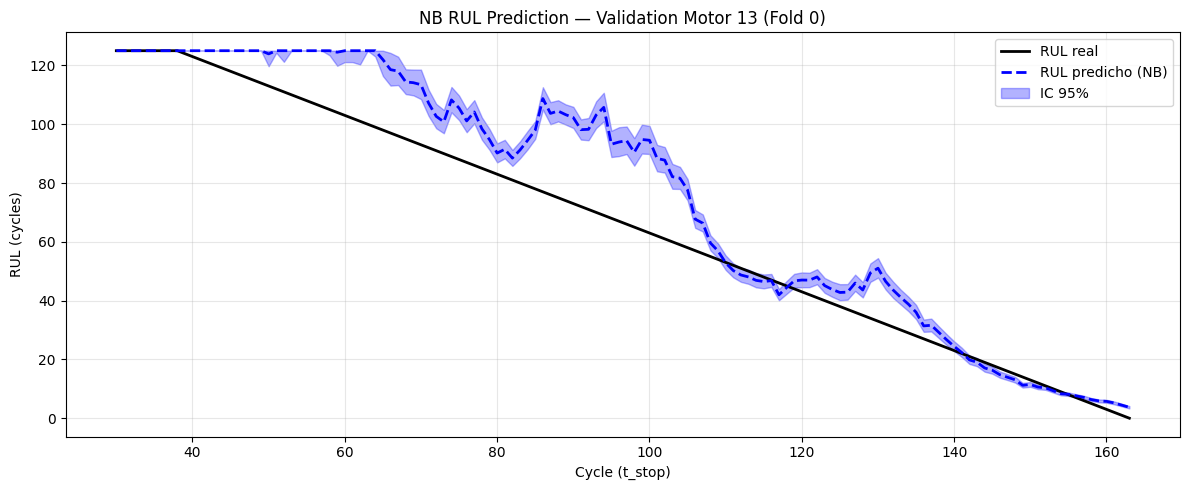


Plot saved to nb_rul_predictions_fold0.png
Total time: 343.8s


In [1]:
"""Pipeline validation script — Phase 5: NB predictions on fold.

Simulates one complete GGS fold and evaluates NegativeBinomialPiecewise
predictions including RUL point estimates and confidence intervals.

Run from the project root or paste into a Jupyter notebook.
"""

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold

from src.dataset_manager import DatasetManager
from src.pipeline.scaling import FeatureScaler
from src.pipeline.windowing import build_windows, flatten_windows
from src.pipeline.feature_extraction import extract_window_features
from src.pipeline.dim_reduction import DimReducer
from src.models.negative_binomial import NegativeBinomialPiecewise

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
WINDOW_SIZE = 30
CLIPPING_THRESHOLD = 125
N_COMPONENTS = 10
N_FOLDS = 5
FOLD_IDX = 0

print("=" * 60)
print("PIPELINE VALIDATION — Phase 5: NB Predictions")
print("=" * 60)

# ---------------------------------------------------------------------------
# Load and split data
# ---------------------------------------------------------------------------
t_total = time.perf_counter()
m_train, _ = DatasetManager.split_dataset()

dfs = []
for idx in m_train:
    df_motor = pd.read_csv(f'data/clean/data_motor_{idx}.csv')
    df_motor.insert(0, 'unit_number', idx)
    dfs.append(df_motor)
df_all = pd.concat(dfs, ignore_index=True)

# GGS separation — only RUL stays out, evento enters pipeline
X_df_full = df_all.drop(columns=['RUL'])
y_df_full = df_all[['unit_number', 'time_in_cycles', 'RUL']]
groups_full = df_all['unit_number'].to_numpy()

gkf = GroupKFold(n_splits=N_FOLDS)
splits = list(gkf.split(X_df_full, groups=groups_full))
train_idx, val_idx = splits[FOLD_IDX]

X_train_df = X_df_full.iloc[train_idx].reset_index(drop=True)
X_val_df   = X_df_full.iloc[val_idx].reset_index(drop=True)
y_train_df = y_df_full.iloc[train_idx].reset_index(drop=True)
y_val_df   = y_df_full.iloc[val_idx].reset_index(drop=True)

# ---------------------------------------------------------------------------
# Nodo 1 — FeatureScaler
# ---------------------------------------------------------------------------
print("\nNodo 1 — scaling...", end=' ', flush=True)
t0 = time.perf_counter()
scaler = FeatureScaler()
scaler.fit(X_train_df)
X_train_scaled: pd.DataFrame = scaler.transform(X_train_df)
X_val_scaled:   pd.DataFrame = scaler.transform(X_val_df)
print(f"{time.perf_counter()-t0:.2f}s")

# ---------------------------------------------------------------------------
# Nodo 2 — build_windows
# ---------------------------------------------------------------------------
print("Nodo 2 — windowing...", end=' ', flush=True)
t0 = time.perf_counter()
train_windows = build_windows(X_train_scaled, WINDOW_SIZE, CLIPPING_THRESHOLD)
val_windows   = build_windows(X_val_scaled,   WINDOW_SIZE, CLIPPING_THRESHOLD)
print(f"{time.perf_counter()-t0:.2f}s")

# ---------------------------------------------------------------------------
# Nodo 3 — extract_window_features
# ---------------------------------------------------------------------------
print("Nodo 3 — feature extraction...", end=' ', flush=True)
t0 = time.perf_counter()
train_features = extract_window_features(train_windows)
val_features   = extract_window_features(val_windows)
print(f"{time.perf_counter()-t0:.1f}s")

# ---------------------------------------------------------------------------
# Nodo 4 — DimReducer
# ---------------------------------------------------------------------------
print("Nodo 4 — PCA...", end=' ', flush=True)
t0 = time.perf_counter()
reducer = DimReducer(n_components=N_COMPONENTS)
reducer.fit(train_features)
train_reduced = reducer.transform(train_features)
val_reduced   = reducer.transform(val_features)
print(f"{time.perf_counter()-t0:.2f}s")

# ---------------------------------------------------------------------------
# Flatten + reconstruct y_rul via merge
# ---------------------------------------------------------------------------
X_train, t_start_tr, t_stop_tr, evento_tr, _, groups_tr = flatten_windows(train_reduced)
X_val,   t_start_val, t_stop_val, evento_val, _, groups_val = flatten_windows(val_reduced)

def reconstruct_y_rul(
    groups: np.ndarray,
    t_stop: np.ndarray,
    y_df: pd.DataFrame,
    clipping: int
) -> np.ndarray:
    """Reconstructs y_rul by merging t_stop with RUL from y_df."""
    df_merge = pd.DataFrame({
        'unit_number': groups,
        'time_in_cycles': t_stop.astype(int),
    })
    merged = df_merge.merge(y_df, on=['unit_number', 'time_in_cycles'], how='left')
    return np.minimum(merged['RUL'].to_numpy(dtype=float), clipping)

y_rul_train = reconstruct_y_rul(groups_tr, t_stop_tr, y_train_df, CLIPPING_THRESHOLD)
y_rul_val   = reconstruct_y_rul(groups_val, t_stop_val, y_val_df, CLIPPING_THRESHOLD)

print(f"\nFlatten:")
print(f"  X_train: {X_train.shape}, NaN in y_rul_train: {np.isnan(y_rul_train).any()}")
print(f"  X_val:   {X_val.shape},   NaN in y_rul_val:   {np.isnan(y_rul_val).any()}")

# ---------------------------------------------------------------------------
# Nodo 5 — NegativeBinomialPiecewise
# ---------------------------------------------------------------------------
print("\nNodo 5 — fitting NB...", end=' ', flush=True)
t0 = time.perf_counter()
model = NegativeBinomialPiecewise(
    alpha=1.0,
    link_type='log',
    clipping_threshold=CLIPPING_THRESHOLD,
)
model.fit(X_train, y_rul_train)
print(f"{time.perf_counter()-t0:.3f}s  (fitted={model.is_fitted_})")

# ---------------------------------------------------------------------------
# Predictions
# ---------------------------------------------------------------------------
print("\n" + "-" * 60)
print("RUL PREDICTIONS — validation set")
print("-" * 60)

rul_pred = model.predict(X_val)
rul_pred_ci, ic_lower, ic_upper = model.predict_with_confidence(X_val, confidence=0.95)

mae  = np.nanmean(np.abs(rul_pred - y_rul_val))
rmse = np.sqrt(np.nanmean((rul_pred - y_rul_val)**2))

print(f"  MAE:  {mae:.2f} cycles")
print(f"  RMSE: {rmse:.2f} cycles")
print(f"  RUL pred range:  {rul_pred.min():.1f} → {rul_pred.max():.1f}")
print(f"  RUL true range:  {y_rul_val.min():.1f} → {y_rul_val.max():.1f}")
print(f"  IC width mean:   {(ic_upper - ic_lower).mean():.2f} cycles")

# ---------------------------------------------------------------------------
# Plot — one validation motor
# ---------------------------------------------------------------------------
val_motor_ids = list(val_reduced.keys())
sample_motor  = val_motor_ids[0]
mask = groups_val == sample_motor

t_stop_m  = t_stop_val[mask]
rul_true_m = y_rul_val[mask]
rul_pred_m = rul_pred[mask]
ic_lo_m    = ic_lower[mask]
ic_hi_m    = ic_upper[mask]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t_stop_m, rul_true_m, 'k-',  linewidth=2, label='RUL real')
ax.plot(t_stop_m, rul_pred_m, 'b--', linewidth=2, label='RUL predicho (NB)')
ax.fill_between(t_stop_m, ic_lo_m, ic_hi_m, alpha=0.3, color='blue',
                label='IC 95%')
ax.set_xlabel('Cycle (t_stop)')
ax.set_ylabel('RUL (cycles)')
ax.set_title(f'NB RUL Prediction — Validation Motor {sample_motor} (Fold {FOLD_IDX})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('nb_rul_predictions_fold0.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nPlot saved to nb_rul_predictions_fold0.png")
print(f"Total time: {time.perf_counter()-t_total:.1f}s")

# SVR pre-check

PIPELINE VALIDATION — Phase 6: SVR Predictions
Training engines: 140
Test engines: 60

Nodo 1 — scaling... 0.23s
Nodo 2 — windowing... 3.70s
Nodo 3 — feature extraction... 535.5s
Nodo 4 — PCA... 5.11s

Nodo 5 — fitting SVR (rbf)... 44.769s  (fitted=True)
Nodo 5 — fitting NB (log)... 0.755s  (fitted=True)

Model         MAE     RMSE
--------------------------
SVR         10.49    15.01
NB          11.16    15.88


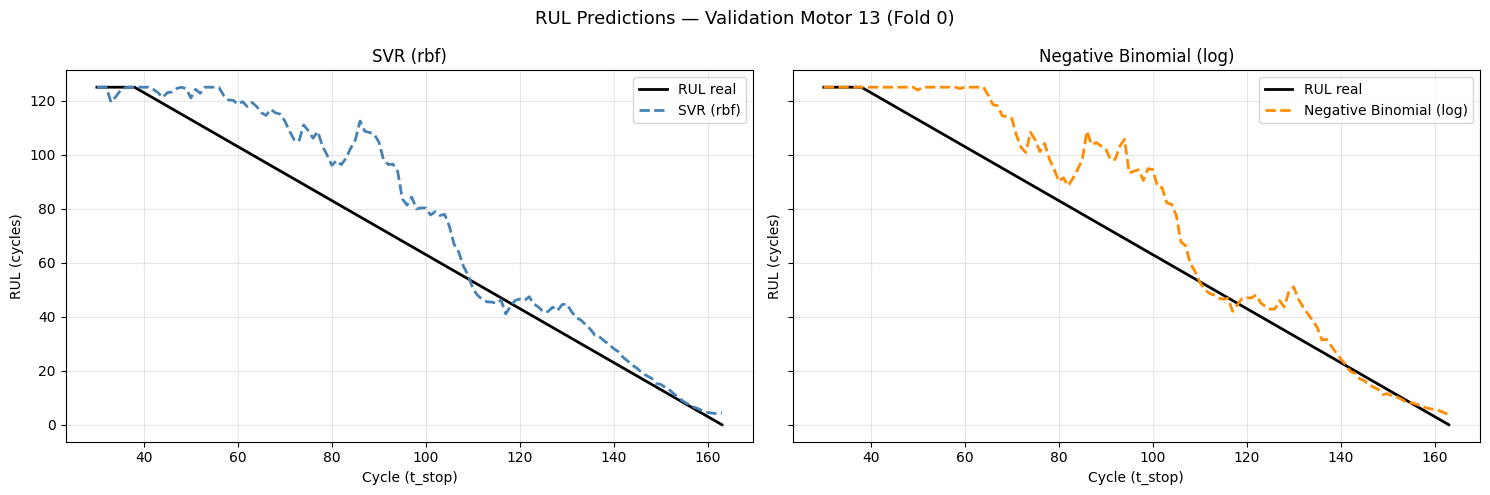


Plot saved to svr_vs_nb_fold0.png
Total time: 609.4s


In [1]:
"""Pipeline validation script — Phase 6: SVR predictions on fold.

Simulates one complete GGS fold and evaluates SVRModel predictions.
Compares SVR vs NB on the same fold for reference.

Run from the project root or paste into a Jupyter notebook.
"""

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold

from src.dataset_manager import DatasetManager
from src.pipeline.scaling import FeatureScaler
from src.pipeline.windowing import build_windows, flatten_windows
from src.pipeline.feature_extraction import extract_window_features
from src.pipeline.dim_reduction import DimReducer
from src.models.svr_model import SVRModel
from src.models.negative_binomial import NegativeBinomialPiecewise

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
WINDOW_SIZE = 30
CLIPPING_THRESHOLD = 125
N_COMPONENTS = 10
N_FOLDS = 5
FOLD_IDX = 0

print("=" * 60)
print("PIPELINE VALIDATION — Phase 6: SVR Predictions")
print("=" * 60)

# ---------------------------------------------------------------------------
# Load and split data
# ---------------------------------------------------------------------------
t_total = time.perf_counter()
m_train, _ = DatasetManager.split_dataset()

dfs = []
for idx in m_train:
    df_motor = pd.read_csv(f'data/clean/data_motor_{idx}.csv')
    df_motor.insert(0, 'unit_number', idx)
    dfs.append(df_motor)
df_all = pd.concat(dfs, ignore_index=True)

X_df_full = df_all.drop(columns=['RUL'])
y_df_full = df_all[['unit_number', 'time_in_cycles', 'RUL']]
groups_full = df_all['unit_number'].to_numpy()

gkf = GroupKFold(n_splits=N_FOLDS)
splits = list(gkf.split(X_df_full, groups=groups_full))
train_idx, val_idx = splits[FOLD_IDX]

X_train_df = X_df_full.iloc[train_idx].reset_index(drop=True)
X_val_df   = X_df_full.iloc[val_idx].reset_index(drop=True)
y_train_df = y_df_full.iloc[train_idx].reset_index(drop=True)
y_val_df   = y_df_full.iloc[val_idx].reset_index(drop=True)

# ---------------------------------------------------------------------------
# Nodos 1-4
# ---------------------------------------------------------------------------
print("\nNodo 1 — scaling...", end=' ', flush=True)
t0 = time.perf_counter()
scaler = FeatureScaler()
scaler.fit(X_train_df)
X_train_scaled: pd.DataFrame = scaler.transform(X_train_df)
X_val_scaled:   pd.DataFrame = scaler.transform(X_val_df)
print(f"{time.perf_counter()-t0:.2f}s")

print("Nodo 2 — windowing...", end=' ', flush=True)
t0 = time.perf_counter()
train_windows = build_windows(X_train_scaled, WINDOW_SIZE, CLIPPING_THRESHOLD)
val_windows   = build_windows(X_val_scaled,   WINDOW_SIZE, CLIPPING_THRESHOLD)
print(f"{time.perf_counter()-t0:.2f}s")

print("Nodo 3 — feature extraction...", end=' ', flush=True)
t0 = time.perf_counter()
train_features = extract_window_features(train_windows)
val_features   = extract_window_features(val_windows)
print(f"{time.perf_counter()-t0:.1f}s")

print("Nodo 4 — PCA...", end=' ', flush=True)
t0 = time.perf_counter()
reducer = DimReducer(n_components=N_COMPONENTS)
reducer.fit(train_features)
train_reduced = reducer.transform(train_features)
val_reduced   = reducer.transform(val_features)
print(f"{time.perf_counter()-t0:.2f}s")

# ---------------------------------------------------------------------------
# Flatten + reconstruct y_rul
# ---------------------------------------------------------------------------
X_train, _, t_stop_tr, _, _, groups_tr = flatten_windows(train_reduced)
X_val,   _, t_stop_val, _, _, groups_val = flatten_windows(val_reduced)

def reconstruct_y_rul(
    groups: np.ndarray,
    t_stop: np.ndarray,
    y_df: pd.DataFrame,
    clipping: int,
) -> np.ndarray:
    df_merge = pd.DataFrame({
        'unit_number': groups,
        'time_in_cycles': t_stop.astype(int),
    })
    merged = df_merge.merge(y_df, on=['unit_number', 'time_in_cycles'], how='left')
    return np.minimum(merged['RUL'].to_numpy(dtype=float), clipping)

y_rul_train = reconstruct_y_rul(groups_tr,  t_stop_tr,  y_train_df, CLIPPING_THRESHOLD)
y_rul_val   = reconstruct_y_rul(groups_val, t_stop_val, y_val_df,   CLIPPING_THRESHOLD)

# ---------------------------------------------------------------------------
# Nodo 5 — SVR
# ---------------------------------------------------------------------------
print("\nNodo 5 — fitting SVR (rbf)...", end=' ', flush=True)
t0 = time.perf_counter()
svr = SVRModel(kernel='rbf', C=1.0, epsilon=0.1, clipping_threshold=CLIPPING_THRESHOLD)
svr.fit(X_train, y_rul_train)
print(f"{time.perf_counter()-t0:.3f}s  (fitted={svr.is_fitted_})")

# Nodo 5 — NB for comparison
print("Nodo 5 — fitting NB (log)...", end=' ', flush=True)
t0 = time.perf_counter()
nb = NegativeBinomialPiecewise(alpha=1.0, link_type='log',
                                clipping_threshold=CLIPPING_THRESHOLD)
nb.fit(X_train, y_rul_train)
print(f"{time.perf_counter()-t0:.3f}s  (fitted={nb.is_fitted_})")

# ---------------------------------------------------------------------------
# Metrics
# ---------------------------------------------------------------------------
rul_svr = svr.predict(X_val)
rul_nb  = nb.predict(X_val)

mae_svr  = np.nanmean(np.abs(rul_svr - y_rul_val))
rmse_svr = np.sqrt(np.nanmean((rul_svr - y_rul_val)**2))
mae_nb   = np.nanmean(np.abs(rul_nb  - y_rul_val))
rmse_nb  = np.sqrt(np.nanmean((rul_nb  - y_rul_val)**2))

print(f"\n{'Model':<8} {'MAE':>8} {'RMSE':>8}")
print("-" * 26)
print(f"{'SVR':<8} {mae_svr:>8.2f} {rmse_svr:>8.2f}")
print(f"{'NB':<8} {mae_nb:>8.2f} {rmse_nb:>8.2f}")

# ---------------------------------------------------------------------------
# Plot — one validation motor
# ---------------------------------------------------------------------------
val_motor_ids = list(val_reduced.keys())
sample_motor  = val_motor_ids[0]
mask = groups_val == sample_motor

t_stop_m   = t_stop_val[mask]
rul_true_m = y_rul_val[mask]
rul_svr_m  = rul_svr[mask]
rul_nb_m   = rul_nb[mask]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
fig.suptitle(f'RUL Predictions — Validation Motor {sample_motor} (Fold {FOLD_IDX})',
             fontsize=13)

for ax, pred, label, color in zip(
    axes,
    [rul_svr_m, rul_nb_m],
    ['SVR (rbf)', 'Negative Binomial (log)'],
    ['steelblue', 'darkorange']
):
    ax.plot(t_stop_m, rul_true_m, 'k-', linewidth=2, label='RUL real')
    ax.plot(t_stop_m, pred, '--', color=color, linewidth=2, label=label)
    ax.set_xlabel('Cycle (t_stop)')
    ax.set_ylabel('RUL (cycles)')
    ax.set_title(label)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('svr_vs_nb_fold0.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to svr_vs_nb_fold0.png")
print(f"Total time: {time.perf_counter()-t_total:.1f}s")

In [1]:
"""Pipeline validation — Orchestrator (RULPipeline).

Validates the RULPipeline orchestrator on a real GGS fold:
- Timing per stage
- Output shapes and alignment
- y_rul reconstruction
- Ready for GGS consumption

Run from project root or paste into Jupyter notebook.
"""

import time
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold

from src.dataset_manager import DatasetManager
from src.pipeline.rul_pipeline import RULPipeline

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
WINDOW_SIZE   = 30
CLIPPING      = 125
N_COMPONENTS  = 10
N_FOLDS       = 5
FOLD_IDX      = 0

print("=" * 60)
print("PIPELINE VALIDATION — RULPipeline Orchestrator")
print("=" * 60)

# ---------------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------------
t_total = time.perf_counter()
m_train, _ = DatasetManager.split_dataset()

dfs = []
for idx in m_train:
    df_motor = pd.read_csv(f'data/clean/data_motor_{idx}.csv')
    df_motor.insert(0, 'unit_number', idx)
    dfs.append(df_motor)
df_all = pd.concat(dfs, ignore_index=True)

# GGS separation
X_df_full = df_all.drop(columns=['RUL'])
y_df_full = df_all[['unit_number', 'time_in_cycles', 'RUL']]
groups_full = df_all['unit_number'].to_numpy()

# ---------------------------------------------------------------------------
# Fold split
# ---------------------------------------------------------------------------
gkf = GroupKFold(n_splits=N_FOLDS)
splits = list(gkf.split(X_df_full, groups=groups_full))
train_idx, val_idx = splits[FOLD_IDX]

X_train_df = X_df_full.iloc[train_idx].reset_index(drop=True)
X_val_df   = X_df_full.iloc[val_idx].reset_index(drop=True)
y_train_df = y_df_full.iloc[train_idx].reset_index(drop=True)
y_val_df   = y_df_full.iloc[val_idx].reset_index(drop=True)

print(f"\nFold {FOLD_IDX}:")
print(f"  Train: {X_train_df['unit_number'].nunique()} motors, {len(X_train_df)} rows")
print(f"  Val:   {X_val_df['unit_number'].nunique()} motors, {len(X_val_df)} rows")

# ---------------------------------------------------------------------------
# RULPipeline — fit_transform on training
# ---------------------------------------------------------------------------
print(f"\n{'─'*60}")
print("fit_transform (training fold)")
print('─'*60)

pipeline = RULPipeline(
    window_size=WINDOW_SIZE,
    clipping_threshold=CLIPPING,
    n_components=N_COMPONENTS,
    verbose=True,
)

t0 = time.perf_counter()
X_train, y_rul_tr, t_stop_tr, evento_tr, groups_tr = pipeline.fit_transform(
    X_train_df, y_train_df
)
t_fit = time.perf_counter() - t0

print(f"\n  Total fit_transform: {t_fit:.1f}s")
print(f"\n  Output validation:")
print(f"    X_train shape:      {X_train.shape}")
print(f"    y_rul_tr NaN:       {np.isnan(y_rul_tr).any()}")
print(f"    y_rul_tr range:     {y_rul_tr.min():.1f} → {y_rul_tr.max():.1f}")
print(f"    t_stop_tr range:    {t_stop_tr.min():.0f} → {t_stop_tr.max():.0f}")
print(f"    evento_tr sum:      {evento_tr.sum()} (train motors with fallo)")
print(f"    groups_tr unique:   {len(np.unique(groups_tr))} motors")
print(f"    X_train NaN:        {np.isnan(X_train).any()}")
print(f"    X_train range:      {X_train.min():.3f} → {X_train.max():.3f}")

evr = pipeline.explained_variance_ratio()
print(f"\n  PCA explained variance:")
print(f"    Per component: {evr.round(3)}")
print(f"    Cumulative:    {evr.cumsum()[-1]:.3f}")

# ---------------------------------------------------------------------------
# RULPipeline — transform on validation
# ---------------------------------------------------------------------------
print(f"\n{'─'*60}")
print("transform (validation fold)")
print('─'*60)

t0 = time.perf_counter()
X_val, y_rul_val, t_stop_val, evento_val, groups_val = pipeline.transform(
    X_val_df, y_val_df
)
t_transform = time.perf_counter() - t0

print(f"\n  Total transform: {t_transform:.1f}s")
print(f"\n  Output validation:")
print(f"    X_val shape:        {X_val.shape}")
print(f"    y_rul_val NaN:      {np.isnan(y_rul_val).any()}")
print(f"    y_rul_val range:    {y_rul_val.min():.1f} → {y_rul_val.max():.1f}")
print(f"    evento_val sum:     {evento_val.sum()} (val motors with fallo)")
print(f"    groups_val unique:  {len(np.unique(groups_val))} motors")
print(f"    X_val NaN:          {np.isnan(X_val).any()}")

# ---------------------------------------------------------------------------
# GGS readiness check
# ---------------------------------------------------------------------------
print(f"\n{'─'*60}")
print("GGS readiness check")
print('─'*60)
print(f"  ✅ X_train ready:    {X_train.shape} — model.fit(X_train, y_rul_tr)")
print(f"  ✅ X_val ready:      {X_val.shape}   — model.predict(X_val)")
print(f"  ✅ y_rul available:  train={not np.isnan(y_rul_tr).any()}, val={not np.isnan(y_rul_val).any()}")
print(f"  ✅ groups ready:     {groups_tr.shape} — GroupKFold compatible")
print(f"  ✅ pipeline fitted:  {pipeline.is_fitted_}")

print(f"\n{'='*60}")
print(f"Total time: {time.perf_counter()-t_total:.1f}s")
print("Pipeline is ready for GGS.")

PIPELINE VALIDATION — RULPipeline Orchestrator
Training engines: 140
Test engines: 60

Fold 0:
  Train: 112 motors, 19062 rows
  Val:   28 motors, 4762 rows

────────────────────────────────────────────────────────────
fit_transform (training fold)
────────────────────────────────────────────────────────────
  Nodo 2 (windowing): 4.73s
  Nodo 3 (features): 330.31s
  Nodo 4 (PCA): 0.97s

  Total fit_transform: 336.2s

  Output validation:
    X_train shape:      (15814, 10)
    y_rul_tr NaN:       False
    y_rul_tr range:     0.0 → 125.0
    t_stop_tr range:    30 → 287
    evento_tr sum:      57 (train motors with fallo)
    groups_tr unique:   112 motors
    X_train NaN:        False
    X_train range:      -12.562 → 27.321

  PCA explained variance:
    Per component: [0.304 0.136 0.047 0.015 0.013 0.012 0.012 0.012 0.011 0.011]
    Cumulative:    0.572

────────────────────────────────────────────────────────────
transform (validation fold)
─────────────────────────────────────────

In [ ]:
import pandas as pd
import numpy as np
from src.dataset_manager import DatasetManager
from src.ggs_training_manager import GGSTrainingManager
from src.models.negative_binomial import NegativeBinomialPiecewise
from src.models.svr_model import SVRModel

# ---------------------------------------------------------------------------
# Preparar datos
# ---------------------------------------------------------------------------
m_train, _ = DatasetManager.split_dataset()

dfs = []
for idx in m_train:
    df = pd.read_csv(f'data/clean/data_motor_{idx}.csv')
    df.insert(0, 'unit_number', idx)
    dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)

X_df = df_all.drop(columns=['RUL'])
y_df = df_all[['unit_number', 'time_in_cycles', 'RUL']]
groups = df_all['unit_number'].to_numpy()

# ---------------------------------------------------------------------------
# GGS — Negative Binomial
# ---------------------------------------------------------------------------
manager_nb = GGSTrainingManager(
    model_class=NegativeBinomialPiecewise,
    X_df=X_df, y_df=y_df, groups=groups,
)
manager_nb.group_grid_search(
    param_grid={
        'window_size':        [20, 30],
        'n_components':       [5, 10],
        'clipping_threshold': [125],
        'alpha':              [0.5, 1.0],
        'link_type':          ['log'],
    },
    n_folds=3,
)
display(manager_nb.get_ggs_results(top_n=5))

## Feature Exploration

In [2]:
"""Feature exploration script — comparing feature sets for RUL pipeline.

Evaluates four feature set configurations on motor 1:
    A — Current:     median, abs_energy, q25, q75 + trend features
    B — RMS swap:    replaces abs_energy with rms
    C — +FFT:        B + fft coefficients (0-5)
    D — +Entropy:    B + permutation entropy

For each configuration measures:
    1. Extraction time (Nodo 3 cost)
    2. Feature range and std (scale before PCA)
    3. PCA explained variance with n_components=10 and 15
    4. Correlation between rms and abs_energy (redundancy check)

Run from project root or paste into Jupyter notebook.
"""

import time
import warnings
import numpy as np
import pandas as pd
from scipy.stats import entropy as scipy_entropy

from src.pipeline.windowing import build_windows, flatten_windows
from src.pipeline.feature_extraction import (
    _compute_features,
    STATISTICAL_FEATURES,
    TREND_FEATURES,
    ALL_FEATURES,
    MotorWindows,
)
from src.pipeline.dim_reduction import DimReducer

warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
WINDOW_SIZE  = 30
CLIPPING     = 125
MOTOR_ID     = 1

print("=" * 60)
print("FEATURE EXPLORATION — Motor 1")
print("=" * 60)

# ---------------------------------------------------------------------------
# Load data and build windows
# ---------------------------------------------------------------------------
df = pd.read_csv(f'data/clean/data_motor_{MOTOR_ID}.csv')
df.insert(0, 'unit_number', MOTOR_ID)
X_df = df.drop(columns=['RUL'])

motor_windows = build_windows(X_df, WINDOW_SIZE, CLIPPING)
X_3d = motor_windows[MOTOR_ID]['X_windows']  # (n_windows, window_size, n_sensors)
n_windows, window_size, n_sensors = X_3d.shape
print(f"\nWindows: {n_windows}, window_size: {window_size}, sensors: {n_sensors}")

# ---------------------------------------------------------------------------
# Helper — compute rms
# ---------------------------------------------------------------------------
def compute_rms(X: np.ndarray) -> np.ndarray:
    """RMS = sqrt(mean(x²)) over window axis. Shape: (n_windows, n_sensors)."""
    return np.sqrt(np.mean(X ** 2, axis=1))

def compute_fft_coefs(X: np.ndarray, n_coefs: int = 5) -> np.ndarray:
    """FFT absolute coefficients 0..n_coefs-1 over window axis.
    Shape: (n_windows, n_coefs * n_sensors)."""
    blocks = []
    for k in range(n_coefs):
        fft_vals = np.fft.rfft(X, axis=1)
        coef_k = np.abs(fft_vals[:, k, :])  # (n_windows, n_sensors)
        blocks.append(coef_k)
    return np.concatenate(blocks, axis=1)

def compute_permutation_entropy(X: np.ndarray, tau: int = 1, dim: int = 3) -> np.ndarray:
    """Permutation entropy per window per sensor.
    Shape: (n_windows, n_sensors). Slow — Python loop."""
    result = np.zeros((n_windows, n_sensors))
    for w in range(n_windows):
        for s in range(n_sensors):
            series = X[w, :, s]
            # Build ordinal patterns
            n = len(series) - (dim - 1) * tau
            if n <= 0:
                continue
            patterns = []
            for i in range(n):
                sub = series[i:i + dim * tau:tau]
                patterns.append(tuple(np.argsort(sub)))
            # Count pattern frequencies
            from collections import Counter
            counts = Counter(patterns)
            total = sum(counts.values())
            probs = np.array([v / total for v in counts.values()])
            result[w, s] = scipy_entropy(probs, base=2)
    return result

# ---------------------------------------------------------------------------
# Feature set definitions
# ---------------------------------------------------------------------------
BASE_TREND = TREND_FEATURES  # slope, rvalue, autocorr x3, partial_autocorr x3

FEATURE_SETS = {
    'A_current':  ('median', 'abs_energy', 'q25', 'q75') + tuple(BASE_TREND),
    'B_rms_swap': ('median', 'rms',        'q25', 'q75') + tuple(BASE_TREND),
    'C_plus_fft': ('median', 'rms',        'q25', 'q75') + tuple(BASE_TREND) + ('fft_0','fft_1','fft_2','fft_3','fft_4'),
    'D_plus_ent': ('median', 'rms',        'q25', 'q75') + tuple(BASE_TREND) + ('perm_entropy',),
}

# ---------------------------------------------------------------------------
# Redundancy check — correlation between rms and abs_energy
# ---------------------------------------------------------------------------
print("\n" + "─" * 60)
print("REDUNDANCY CHECK — rms vs abs_energy")
print("─" * 60)

abs_energy = np.sum(X_3d ** 2, axis=1).flatten()
rms_vals   = np.sqrt(np.mean(X_3d ** 2, axis=1)).flatten()
correlation = np.corrcoef(abs_energy, rms_vals)[0, 1]
print(f"  Pearson correlation(abs_energy, rms): {correlation:.6f}")
print(f"  abs_energy range: {abs_energy.min():.2f} → {abs_energy.max():.2f}")
print(f"  rms range:        {rms_vals.min():.4f} → {rms_vals.max():.4f}")
print(f"  → {'REDUNDANT (r>0.99)' if abs(correlation) > 0.99 else 'NOT redundant'}")

# ---------------------------------------------------------------------------
# Timing and scale per feature set
# ---------------------------------------------------------------------------
print("\n" + "─" * 60)
print("TIMING AND SCALE PER FEATURE SET")
print("─" * 60)

results = {}

for name, features in FEATURE_SETS.items():
    t0 = time.perf_counter()

    # Build feature matrix for this set
    # Split into standard features and custom ones
    std_features = [f for f in features if f in ALL_FEATURES]
    custom = [f for f in features if f not in ALL_FEATURES]

    blocks = []

    # Standard features via _compute_features
    if std_features:
        X_std = _compute_features(X_3d, std_features)
        blocks.append(X_std)

    # Custom features
    for feat in custom:
        if feat == 'rms':
            blocks.append(compute_rms(X_3d))
        elif feat.startswith('fft_'):
            k = int(feat.split('_')[1])
            fft_vals = np.fft.rfft(X_3d, axis=1)
            blocks.append(np.abs(fft_vals[:, k, :]))
        elif feat == 'perm_entropy':
            print(f"    [{name}] Computing permutation entropy (slow)...",
                  end=' ', flush=True)
            blocks.append(compute_permutation_entropy(X_3d))

    X_feat = np.concatenate(blocks, axis=1)
    elapsed = time.perf_counter() - t0

    results[name] = {'X': X_feat, 'time': elapsed, 'n_features': X_feat.shape[1]}

    print(f"\n  [{name}]")
    print(f"    Features:   {len(features)} types × {n_sensors} sensors = {X_feat.shape[1]} cols")
    print(f"    Time:       {elapsed:.2f}s")
    print(f"    Range:      {X_feat.min():.4f} → {X_feat.max():.4f}")
    print(f"    Std range:  {X_feat.std(axis=0).min():.4f} → {X_feat.std(axis=0).max():.4f}")

# ---------------------------------------------------------------------------
# PCA variance comparison
# ---------------------------------------------------------------------------
print("\n" + "─" * 60)
print("PCA EXPLAINED VARIANCE COMPARISON")
print("─" * 60)

for n_comp in [10, 15]:
    print(f"\n  n_components = {n_comp}:")
    for name, res in results.items():
        X = res['X']
        # Simulate DimReducer (RobustScaler + PCA)
        from sklearn.preprocessing import RobustScaler
        from sklearn.decomposition import PCA
        X_scaled = RobustScaler().fit_transform(X)
        pca = PCA(n_components=n_comp)
        pca.fit(X_scaled)
        cumvar = pca.explained_variance_ratio_.cumsum()[-1]
        pc1 = pca.explained_variance_ratio_[0]
        print(f"    {name:<16}: cumvar={cumvar:.3f}, PC1={pc1:.3f}")

# ---------------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------------
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  {'Set':<16} {'Time(s)':>8} {'n_feat':>7} {'Speedup vs A':>14}")
t_a = results['A_current']['time']
for name, res in results.items():
    speedup = t_a / res['time'] if res['time'] > 0 else 0
    marker = '← baseline' if name == 'A_current' else f'×{speedup:.1f} faster' if speedup > 1 else f'×{1/speedup:.1f} slower'
    print(f"  {name:<16} {res['time']:>8.2f} {res['n_features']:>7} {marker:>14}")

FEATURE EXPLORATION — Motor 1

Windows: 163, window_size: 30, sensors: 16

────────────────────────────────────────────────────────────
REDUNDANCY CHECK — rms vs abs_energy
────────────────────────────────────────────────────────────
  Pearson correlation(abs_energy, rms): 0.974466
  abs_energy range: 0.00 → 2457972797.70
  rms range:        0.0002 → 9051.6533
  → NOT redundant

────────────────────────────────────────────────────────────
TIMING AND SCALE PER FEATURE SET
────────────────────────────────────────────────────────────

  [A_current]
    Features:   12 types × 16 sensors = 192 cols
    Time:       11.79s
    Range:      -0.7977 → 2457972797.7024
    Std range:  0.0000 → 1617552.5494

  [B_rms_swap]
    Features:   12 types × 16 sensors = 192 cols
    Time:       9.00s
    Range:      -0.7977 → 9055.3975
    Std range:  0.0000 → 6.8673

  [C_plus_fft]
    Features:   17 types × 16 sensors = 272 cols
    Time:       5.00s
    Range:      -0.7977 → 271549.5600
    Std range:  